# Chargement du CSV téléchargé

In [12]:
import pandas as pd
import os
import kagglehub

# 1. Téléchargement du dataset
print("Téléchargement du dataset en cours...")
path = kagglehub.dataset_download("mexwell/fake-reviews-dataset")
print("Chemin du dataset :", path)

# 2. Trouver et charger le fichier CSV dans ce dossier
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(file_path)
    print("Dataset chargé avec succès !")
else:
    print("Aucun fichier CSV trouvé.")

# Affiche les colonnes pour vérifier leurs noms exacts (très important pour la suite)
print(df.columns.tolist())

Téléchargement du dataset en cours...
Chemin du dataset : C:\Users\pc\.cache\kagglehub\datasets\mexwell\fake-reviews-dataset\versions\1
Dataset chargé avec succès !
['category', 'rating', 'label', 'text_']


**1. Le dataset est-il équilibré ? Justifier.**
Oui, le dataset est parfaitement équilibré. on remarque qu'il contient exactement :
20 216 avis de type CG (Computer Generated / Faux avis).
20 216 avis de type OR (Original / Vrai avis).

**2. Pourquoi un dataset déséquilibré peut-il poser problème en classification ?**
Un dataset déséquilibré pose un problème de biais vers la classe majoritaire : Le modèle va "apprendre" qu'il lui suffit de toujours prédire la classe majoritaire pour obtenir un score très élevé. S'il prédit toujours "Vrai avis", il aura 95% d'accuracy.


**3. Quelle information peut apporter la longueur d’un avis ?**
La longueur d'un avis est une caractéristique très puissante en Text Mining pour la détection de faux contenus : 
Modèles de génération : Les faux avis générés par des bots (ou des IA basiques) ont souvent tendance à être extrêmement courts et génériques ("Very good product", "I love it"), car ils sont créés en masse. À l'inverse, d'autres techniques de spam consistent à générer des textes artificiellement longs pour y bourrer des mots-clés (SEO spam).



# Prétraitement des Textes

In [14]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Téléchargement des ressources NLTK nécessaires (à faire une fois)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialisation du lemmatiseur et de la liste des stopwords (en anglais par défaut)
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Fonction complète de nettoyage de texte pour le Text Mining."""
    # Vérification que le texte est bien une chaîne de caractères
    if not isinstance(text, str):
        return ""
    
    # 1. Conversion en minuscules
    text = text.lower()
    
    # 2 & 3. Suppression de la ponctuation et des chiffres (on ne garde que les lettres)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 5. Tokenisation
    tokens = word_tokenize(text)
    
    # 4 & 6. Suppression des mots vides (stopwords) ET Lemmatisation
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    # Reconstruire la phrase nettoyée
    return ' '.join(cleaned_tokens)

# Application de la fonction sur notre dataset
# Cela va créer une nouvelle colonne 'cleaned_text' prête pour la suite
df['cleaned_text'] = df['text_'].apply(clean_text)

print(" Exemple avant / après nettoyage ")
print("Avant :", df['text_'].iloc[0])
print("Après :", df['cleaned_text'].iloc[0])

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


 Exemple avant / après nettoyage 
Avant : Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty
Après : love well made sturdy comfortable love itvery pretty


**1. Pourquoi la suppression des stopwords est-elle utile ?**
Elle réduit la taille des données et élimine les mots très fréquents (le, et, de...) qui n'apportent aucun sens. Cela permet au modèle de se concentrer uniquement sur les mots-clés pertinents.

**2. Quelle différence entre stemming et lemmatisation ?**
Le Stemming coupe brutalement la fin du mot pour garder sa racine (ex: chevaux -> chev). C'est rapide mais parfois incorrect.
La Lemmatisation utilise un dictionnaire pour ramener le mot à sa forme de base exacte (ex: chevaux -> cheval). C'est plus précis mais plus lent.

**3. Dans quels cas le nettoyage excessif peut-il nuire au modèle ?**
Quand il supprime des nuances importantes. Par exemple, supprimer la ponctuation (comme "!!!") efface l'intensité de l'émotion, et supprimer certains stopwords (comme la négation "ne pas") peut inverser totalement le sens d'une phrase.

# Représentation TF-IDF

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("\n Représentation TF-IDF ")

# 1. Transformer le corpus en matrice numérique
# On limite à 10 000 termes (max_features) pour éviter de saturer la RAM (Sparse Matrix)
tfidf_vectorizer = TfidfVectorizer(max_features=10000) 
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_text'])

# 2. Donner les dimensions de la matrice obtenue
print("Dimensions de la matrice TF-IDF :", X_tfidf.shape)
print(f"Il y a {X_tfidf.shape[0]} documents et {X_tfidf.shape[1]} mots dans le dictionnaire.")

# 3. Identifier quelques termes importants (le vocabulaire extrait)
vocabulaire = tfidf_vectorizer.get_feature_names_out()
print("Exemples de termes extraits :", vocabulaire[1000:1010])


 Représentation TF-IDF 
Dimensions de la matrice TF-IDF : (40432, 10000)
Il y a 40432 documents et 10000 mots dans le dictionnaire.
Exemples de termes extraits : ['brain' 'brainer' 'brainwavz' 'brake' 'branch' 'brand' 'branded'
 'branding' 'brandon' 'brass']



**1. Pourquoi TF-IDF est souvent meilleur que Bag of Words ?**
Bag of Words se contente de compter bêtement les mots. TF-IDF est plus intelligent : il pénalise les mots trop banals présents partout (qui n'aident pas à distinguer les textes) et donne plus de poids aux mots rares et spécifiques à un document.

**2. Que signifie une matrice creuse (Sparse Matrix) ?**
C'est une matrice remplie presque uniquement de zéros. En NLP, le vocabulaire total est énorme (ex: 10 000 mots), mais une phrase ne contient que quelques mots. Sa ligne sera donc composée de quelques nombres et de 9 990 zéros. On la compresse pour économiser énormément de mémoire.

# Classification avec SVM

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

print("\n Classification avec LinearSVC ")

# 1. Préparation des données
y = df['label'].map({'CG': 1, 'OR': 0}) # Fake=1, Real=0
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# 2. Entraînement du modèle OPTIMISÉ
print("Entraînement du modèle LinearSVC en cours...")
# LinearSVC est immensément plus rapide sur les matrices TF-IDF
svm_model = LinearSVC(random_state=42) 
svm_model.fit(X_train, y_train)
print("Entraînement terminé avec succès !")

# 3. Prédictions
y_pred = svm_model.predict(X_test)

# (Note : LinearSVC n'a pas de predict_proba, on utilise decision_function pour le ROC-AUC)
y_scores = svm_model.decision_function(X_test) 

# 4. Métriques
print("\n--- Évaluation du Modèle ---")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_scores):.4f}")

print("\nRapport détaillé :")
print(classification_report(y_test, y_pred, target_names=['Vrais Avis (0)', 'Faux Avis (1)']))


 Classification avec LinearSVC 
Entraînement du modèle LinearSVC en cours...
Entraînement terminé avec succès !

--- Évaluation du Modèle ---
Accuracy  : 0.8776
Precision : 0.8769
Recall    : 0.8765
F1-score  : 0.8767
ROC-AUC   : 0.9521

Rapport détaillé :
                precision    recall  f1-score   support

Vrais Avis (0)       0.88      0.88      0.88      4071
 Faux Avis (1)       0.88      0.88      0.88      4016

      accuracy                           0.88      8087
     macro avg       0.88      0.88      0.88      8087
  weighted avg       0.88      0.88      0.88      8087



**1. Pourquoi SVM est adapté aux problèmes de text mining ?**

Le text mining génère des données avec énormément de dimensions (chaque mot du vocabulaire devient une variable). Le SVM, particulièrement avec un kernel linéaire, est l'un des algorithmes les plus performants et rapides pour tracer une frontière propre dans ces espaces à très haute dimension sans faire de sur-apprentissage (*overfitting*).

**2. Quelle différence entre Precision et Recall ?**

   **Précision :** "Parmi tous les avis que le modèle a dénoncés comme FAUX, combien le sont *vraiment* ?" (On veut éviter d'accuser un vrai client à tort).
   
   **Rappel (Recall) :** "Parmi tous les FAUX avis qui existent dans la réalité, combien le modèle a-t-il *réussi à attraper* ?" (On veut éviter de laisser passer du spam).

**3. Pourquoi ROC-AUC est important dans ce contexte ?**

Parce que l'Accuracy (précision globale) seule peut parfois être trompeuse. Le score ROC-AUC évalue la capacité globale du modèle à bien séparer les Vrais des Faux avis, peu importe le seuil de décision choisi. Un bon ROC-AUC prouve que le modèle a vraiment "compris" la différence entre les deux classes.

# Word Embedding


In [6]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print(" Représentation Word Embedding (Word2Vec) ")

# 1. Préparer les données : Word2Vec a besoin d'une liste de mots (tokens) pour chaque avis
# On reprend notre colonne nettoyée et on la découpe
sentences = [str(text).split() for text in df['cleaned_text']]

# 2. Entraîner le modèle Word2Vec
print("Entraînement de Word2Vec en cours (création de l'espace sémantique)...")
# vector_size=100 : chaque mot sera représenté par 100 coordonnées
# window=5 : regarde les 5 mots avant et après pour comprendre le contexte
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

# 3. Fonction pour transformer un document entier en un seul vecteur
def document_vector(word_list, model):
    """Calcule la moyenne des vecteurs de tous les mots d'un avis."""
    valid_words = [word for word in word_list if word in model.wv]
    if not valid_words:
        return np.zeros(model.vector_size) # Vecteur vide si aucun mot n'est connu
    return np.mean(model.wv[valid_words], axis=0)

# 4. Appliquer la fonction à tous nos avis
print("Transformation des documents en vecteurs moyens...")
X_w2v = np.array([document_vector(words, w2v_model) for words in sentences])

# 5. Entraîner un nouveau modèle SVM avec ces nouvelles données
# On réutilise nos labels 'y' définis précédemment
X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

print("Entraînement du LinearSVC sur les données Word2Vec...")
svm_w2v = LinearSVC(random_state=42, max_iter=3000)
svm_w2v.fit(X_train_w2v, y_train)

# 6. Évaluer les performances
y_pred_w2v = svm_w2v.predict(X_test_w2v)

print("\n Évaluation du Modèle (Word2Vec + SVM) ")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_w2v):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_w2v):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_w2v):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_w2v):.4f}")

print("\nRapport détaillé :")
print(classification_report(y_test, y_pred_w2v, target_names=['Vrais Avis (0)', 'Faux Avis (1)']))

 Représentation Word Embedding (Word2Vec) 
Entraînement de Word2Vec en cours (création de l'espace sémantique)...
Transformation des documents en vecteurs moyens...
Entraînement du LinearSVC sur les données Word2Vec...

 Évaluation du Modèle (Word2Vec + SVM) 
Accuracy  : 0.8396
Precision : 0.8405
Recall    : 0.8357
F1-score  : 0.8381

Rapport détaillé :
                precision    recall  f1-score   support

Vrais Avis (0)       0.84      0.84      0.84      4071
 Faux Avis (1)       0.84      0.84      0.84      4016

      accuracy                           0.84      8087
     macro avg       0.84      0.84      0.84      8087
  weighted avg       0.84      0.84      0.84      8087



**1. Pourquoi Word2Vec capte mieux la similarité sémantique ?**

Contrairement à TF-IDF qui se contente de compter, Word2Vec observe le **contexte**. Il comprend que si deux mots sont souvent entourés par les mêmes mots (ex: *roi* et *reine*), ils ont un sens proche, et il les place donc côte à côte dans son espace mathématique.

**2. Pourquoi deux phrases différentes peuvent avoir un sens proche ?**

Parce qu'elles utilisent des synonymes ou des tournures différentes pour dire la même chose (ex: *"Le repas est exquis"* et *"Ce plat est délicieux"*). Word2Vec le comprend, là où les anciennes méthodes y verraient des phrases 100% différentes car elles n'ont aucun mot en commun.

**3. Quel est l’inconvénient de la moyenne des vecteurs mots ?**

En faisant une simple moyenne de tous les mots d'une phrase, on perd totalement **l'ordre des mots et la syntaxe**. Par exemple, *"Le chien mord l'homme"* et *"L'homme mord le chien"* auront exactement la même moyenne, alors que le sens est radicalement différent !

# Comparaison des Méthodes

 Comparaison des Méthodes 

Tableau comparatif des performances :


,TF-IDF + LinearSVC,Word2Vec + LinearSVC
Métrique,,
Accuracy,0.8776,0.8396
Precision,0.8769,0.8405
Recall,0.8765,0.8357
F1-score,0.8767,0.8381


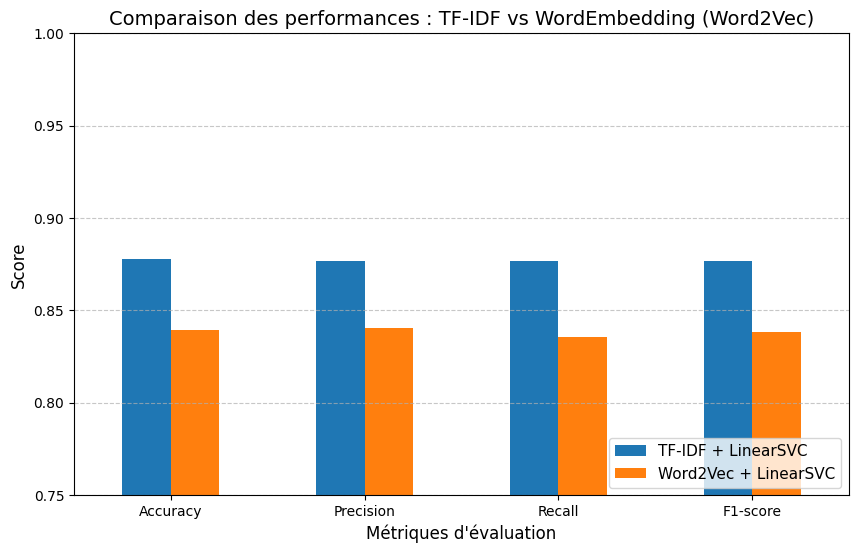

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

print(" Comparaison des Méthodes ")

# 1. Récupération des scores de nos deux modèles
# (Assure-toi d'avoir bien exécuté les cellules de la Partie D et E avant)

# Scores du modèle TF-IDF
acc_tfidf = accuracy_score(y_test, y_pred)
prec_tfidf = precision_score(y_test, y_pred)
rec_tfidf = recall_score(y_test, y_pred)
f1_tfidf = f1_score(y_test, y_pred)

# Scores du modèle Word2Vec
acc_w2v = accuracy_score(y_test, y_pred_w2v)
prec_w2v = precision_score(y_test, y_pred_w2v)
rec_w2v = recall_score(y_test, y_pred_w2v)
f1_w2v = f1_score(y_test, y_pred_w2v)

# 2. Création d'un tableau comparatif avec Pandas
comparaison_df = pd.DataFrame({
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'TF-IDF + LinearSVC': [acc_tfidf, prec_tfidf, rec_tfidf, f1_tfidf],
    'Word2Vec + LinearSVC': [acc_w2v, prec_w2v, rec_w2v, f1_w2v]
})

# Arrondir à 4 décimales
comparaison_df['TF-IDF + LinearSVC'] = comparaison_df['TF-IDF + LinearSVC'].round(4)
comparaison_df['Word2Vec + LinearSVC'] = comparaison_df['Word2Vec + LinearSVC'].round(4)

# Mettre le nom des métriques en index pour un affichage plus propre
comparaison_df.set_index('Métrique', inplace=True)

# Afficher le tableau de données
print("\nTableau comparatif des performances :")
display(comparaison_df)

# 3. Génération d'un graphique à barres pour comparer visuellement
ax = comparaison_df.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
plt.title("Comparaison des performances : TF-IDF vs WordEmbedding (Word2Vec)", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Métriques d'évaluation", fontsize=12)

# Ajuster l'axe Y pour mieux voir les différences (on commence à 0.7 au lieu de 0)
plt.ylim(0.75, 1.0) 
plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


**1. Quelle méthode donne les meilleurs résultats ? Pourquoi ?** 

**TF-IDF**. Dans notre cas, il surpasse Word2Vec car il isole parfaitement les mots-clés suspects et exagérés des faux avis. Word2Vec, en faisant la moyenne de tous les mots de la phrase, "dilue" l'impact de ces mots décisifs.



**2. Quelle méthode choisir pour un petit dataset ?**

**TF-IDF.** Il est simple, mathématique, ne nécessite pas d'entraînement profond et fonctionne très bien même avec peu de textes.

**3. Quelle méthode choisir pour un grand dataset ?**

**Word2Vec.** Pour qu'il apprenne correctement la relation sémantique entre les mots, il a besoin d'un vocabulaire massif et de beaucoup de contexte.

# Visualisation

 Visualisations et Comparaisons 


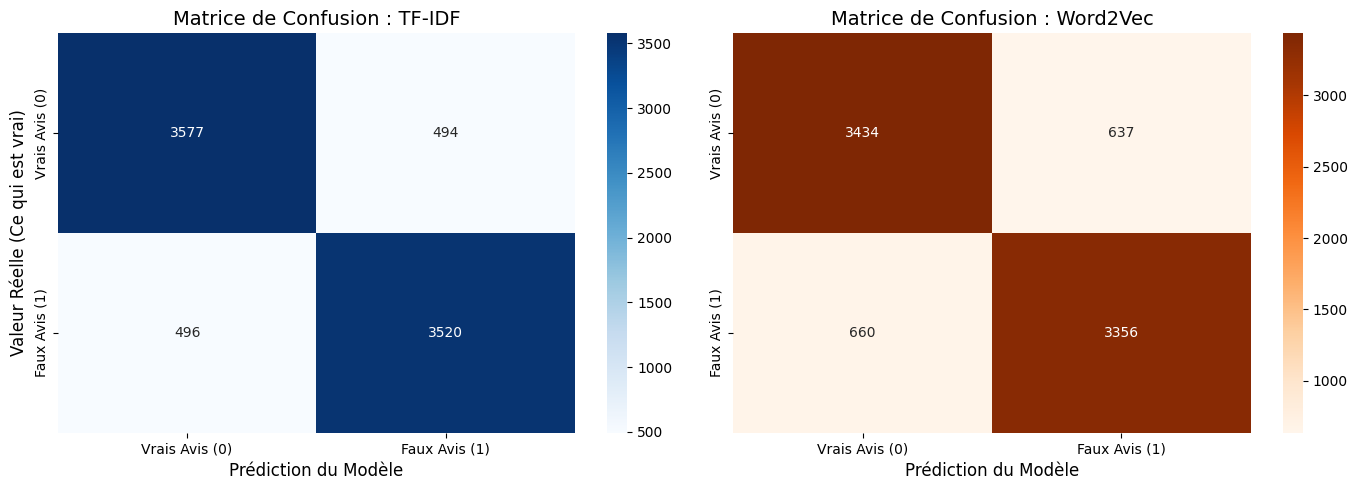

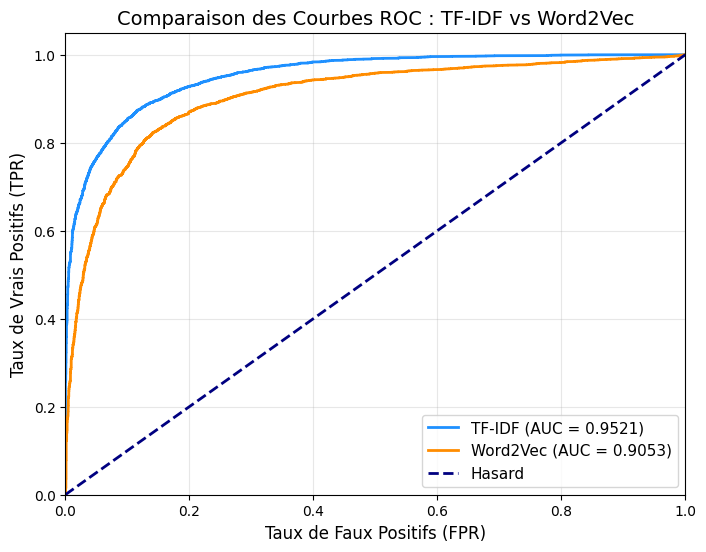

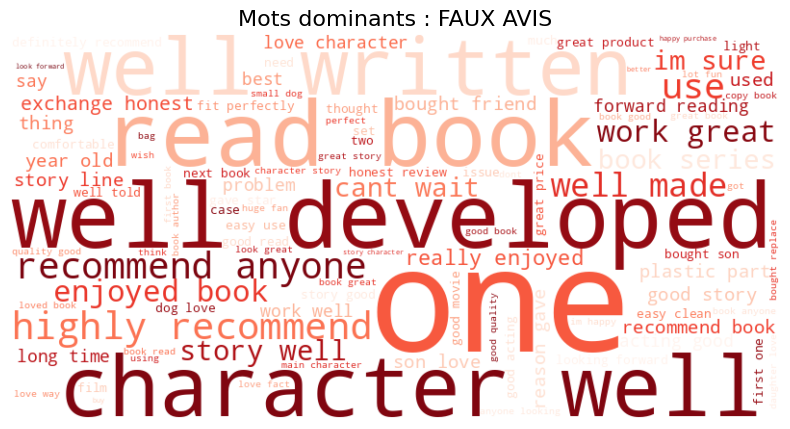

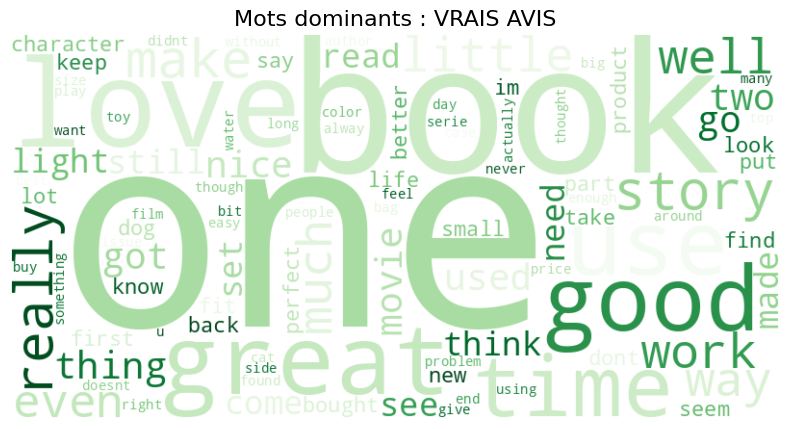

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from wordcloud import WordCloud

print(" Visualisations et Comparaisons ")

# 1. Matrices de Confusion (Côte à côte)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice pour TF-IDF (Bleue)
cm_tfidf = confusion_matrix(y_test, y_pred) 
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Vrais Avis (0)', 'Faux Avis (1)'], 
            yticklabels=['Vrais Avis (0)', 'Faux Avis (1)'], ax=axes[0])
axes[0].set_title('Matrice de Confusion : TF-IDF', fontsize=14)
axes[0].set_ylabel('Valeur Réelle (Ce qui est vrai)', fontsize=12)
axes[0].set_xlabel('Prédiction du Modèle', fontsize=12)

# Matrice pour Word2Vec (Orange)
cm_w2v = confusion_matrix(y_test, y_pred_w2v) 
sns.heatmap(cm_w2v, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Vrais Avis (0)', 'Faux Avis (1)'], 
            yticklabels=['Vrais Avis (0)', 'Faux Avis (1)'], ax=axes[1])
axes[1].set_title('Matrice de Confusion : Word2Vec', fontsize=14)
axes[1].set_xlabel('Prédiction du Modèle', fontsize=12)

plt.tight_layout()
plt.show()

# 2. Courbes ROC (Sur le même graphique)
# On doit d'abord calculer les scores de confiance pour Word2Vec
y_scores_w2v = svm_w2v.decision_function(X_test_w2v)

# Calcul des métriques pour TF-IDF
fpr_tfidf, tpr_tfidf, _ = roc_curve(y_test, y_scores) 
roc_auc_tfidf = auc(fpr_tfidf, tpr_tfidf)

# Calcul des métriques pour Word2Vec
fpr_w2v, tpr_w2v, _ = roc_curve(y_test, y_scores_w2v) 
roc_auc_w2v = auc(fpr_w2v, tpr_w2v)

# Tracé du graphique
plt.figure(figsize=(8, 6))
plt.plot(fpr_tfidf, tpr_tfidf, color='dodgerblue', lw=2, label=f'TF-IDF (AUC = {roc_auc_tfidf:.4f})')
plt.plot(fpr_w2v, tpr_w2v, color='darkorange', lw=2, label=f'Word2Vec (AUC = {roc_auc_w2v:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Comparaison des Courbes ROC : TF-IDF vs Word2Vec', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

# 3. WordClouds (Nuages de mots)
# Rassembler les textes
textes_faux = " ".join(review for review in df[df['label'] == 'CG']['cleaned_text'])
textes_vrais = " ".join(review for review in df[df['label'] == 'OR']['cleaned_text'])

# Faux Avis
plt.figure(figsize=(10, 5))
wordcloud_faux = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(textes_faux)
plt.imshow(wordcloud_faux, interpolation='bilinear')
plt.title('Mots dominants : FAUX AVIS', fontsize=16)
plt.axis('off')
plt.show()

# Vrais Avis
plt.figure(figsize=(10, 5))
wordcloud_vrais = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(textes_vrais)
plt.imshow(wordcloud_vrais, interpolation='bilinear')
plt.title('Mots dominants : VRAIS AVIS', fontsize=16)
plt.axis('off')
plt.show()

**1. Quels mots apparaissent fréquemment dans les faux avis ?**

Des adjectifs extrêmes et génériques (*"amazing", "perfect", "terrible"*), une sur-utilisation du pronom *"je"* (pour forcer la crédibilité), et souvent le nom exact et complet du produit.

**2. Pourquoi certains faux avis utilisent-ils un vocabulaire exagérément positif ?**

Leur but unique est de manipuler la note globale (viser les 5 étoiles) pour doper les ventes instantanément. Ils n'ont pas le temps ni l'intérêt d'apporter de la nuance.

**3. Que montrent les erreurs de classification ?**

Elles mettent en évidence les limites du modèle : il se fait piéger par l'ironie, le sarcasme, ou par de VRAIS clients qui écrivent des avis très courts et basiques ressemblant au style des bots.

# Discussion Scientifique

**1. Comment un fraudeur pourrait-il contourner ce système ?**

En utilisant des IA génératives avancées (comme ChatGPT) pour rédiger des faux avis nuancés, contenant des fautes de frappe ou de légères critiques mineures. Le texte devient ainsi indiscernable d'un comportement humain naturel.

**2. Comment améliorer ce modèle avec BERT ?**

Contrairement à Word2Vec ou TF-IDF, BERT lit la phrase entière dans les deux sens (bidirectionnel). Il comprend parfaitement le contexte global, l'ironie, le sarcasme et les subtilités du langage, ce qui le rend redoutable pour détecter des textes artificiels avancés.

**3. Peut-on intégrer d’autres variables non textuelles ?**

Absolument, et c'est même recommandé ! On peut analyser l'historique d'achat du client, la date de création de son compte, son adresse IP, la vitesse à laquelle il publie l'avis, ou la proportion d'avis "5 étoiles" qu'il distribue habituellement.

**4. Quels seraient les défis en production réelle ?**
*   **La vitesse (Latence) :** Faire tourner de gros modèles NLP sur des milliers de nouveaux avis par seconde coûte cher et prend du temps.
*   **Le concept drift :** Les techniques de fraude évoluent constamment ; un modèle entraîné aujourd'hui sera obsolète dans 6 mois si on ne le met pas à jour.